# 06 Exploratory Structure Analysis

This notebook explores the underlying structure of the preprocessed dataset using unsupervised learning techniques, specifically Principal Component Analysis (PCA) and K-Means Clustering. This analysis provides supporting evidence to understand feature redundancy and data distribution but is not used for final model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Setup styling
plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (10, 6)
})
COLORS = ['#475ED1', '#E3120B', '#5DBB63', '#FFD700']

# Add src to path
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_and_split_data, get_preprocessing_pipeline

def save_and_show(fig_name: str):
    """Saves figure to outputs/figures and shows it."""
    out_dir = PROJECT_ROOT / "outputs" / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / f"{fig_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "adult_cleaned.csv"
print("Setup complete.")

Setup complete.


## 1. Data Preparation

We reload and split the data using the established `random_state=42` and apply the standard preprocessing pipeline (fit on training data only).

In [2]:
# Load and split
df_train, df_val, df_test = load_and_split_data(DATA_PATH, random_state=42)

# Separate features and target
target = 'income'
X_train, y_train = df_train.drop(columns=[target]), (df_train[target] == '>50K').astype(int)
X_val, y_val = df_val.drop(columns=[target]), (df_val[target] == '>50K').astype(int)

# Define feature groups
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Preprocess (scale=True is essential for PCA/KMeans)
preprocessor = get_preprocessing_pipeline(num_cols, cat_cols, scale=True)
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

print(f"Preprocessed Train shape: {X_train_proc.shape}")

Preprocessed Train shape: (39073, 67)


## 2. Principal Component Analysis (PCA)

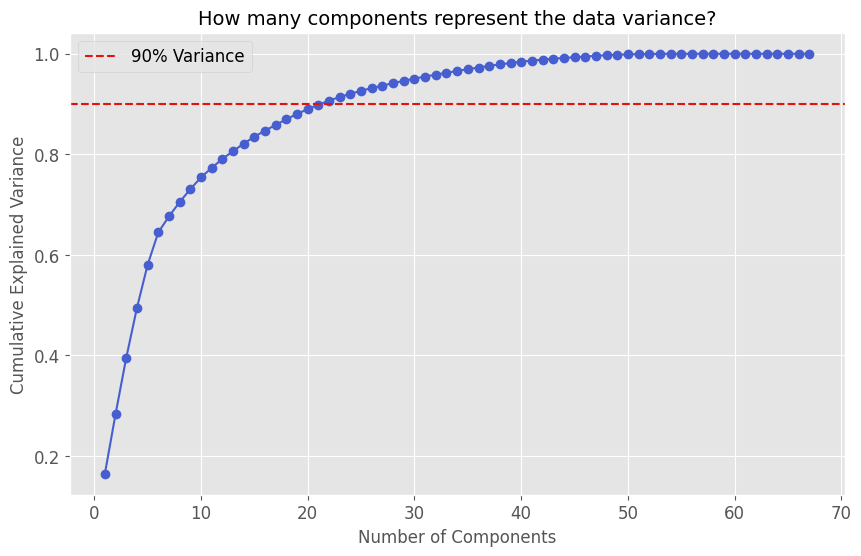

In [4]:
pca = PCA(random_state=42)
pca.fit(X_train_proc)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color=COLORS[0])
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('How many components represent the data variance?')
plt.axhline(y=0.90, color=COLORS[1], linestyle='--', label='90% Variance')
plt.legend()
save_and_show('structure_pca_variance')

### 2D Visualization (PC1 vs PC2)

We project a sample of the data into the first two principal components to look for visually distinct class separation.

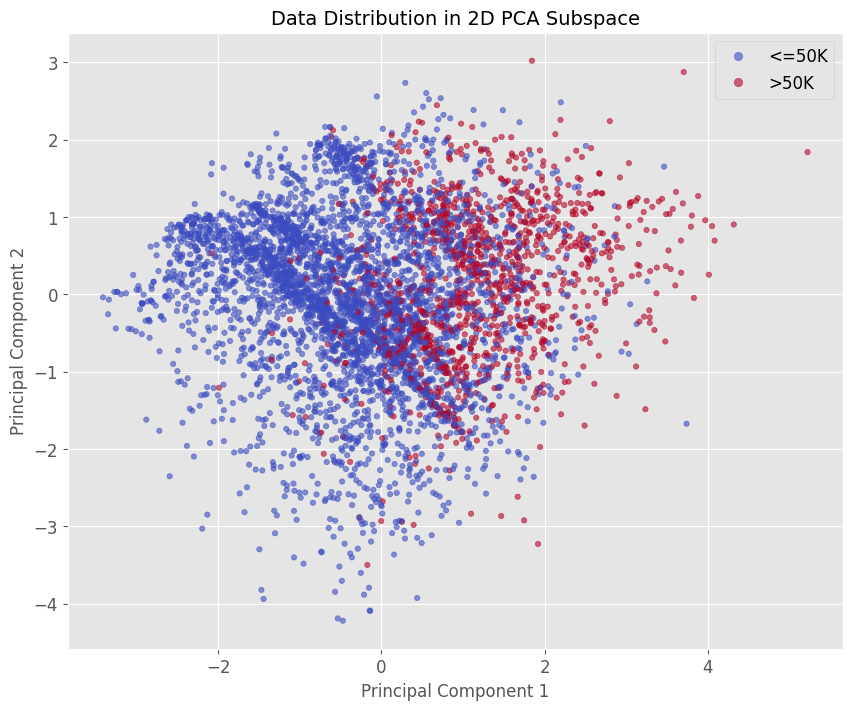

In [5]:
X_train_pca = pca.transform(X_train_proc)

# Sample for visualization
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_pca), 5000, replace=False)
X_sample = X_train_pca[sample_idx]
y_sample = y_train.iloc[sample_idx]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_sample[:, 0], X_sample[:, 1], c=y_sample, cmap='coolwarm', alpha=0.6, s=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Data Distribution in 2D PCA Subspace')
plt.legend(handles=scatter.legend_elements()[0], labels=['<=50K', '>50K'])
save_and_show('structure_pca_scatter')

**Interpretation:**
The cumulative variance plot shows that a significant number of components are required to capture the majority of the variance, suggesting high dimensionality. The 2D scatter plot reveals substantial overlap between the two income classes, indicating that the target cannot be easily separated by the first two linear projections of the feature space.

## 3. Clustering Exploration

We apply K-Means clustering to a reduced representation (first 10 components) to find unsupervised groupings.


--- KMeans (k=2) ---
Silhouette Score: 0.3423

Cross-tab (Cluster vs Label):
Income       0     1
Cluster             
0         1213  1970
1        28511  7379
Overall Purity: 0.7801


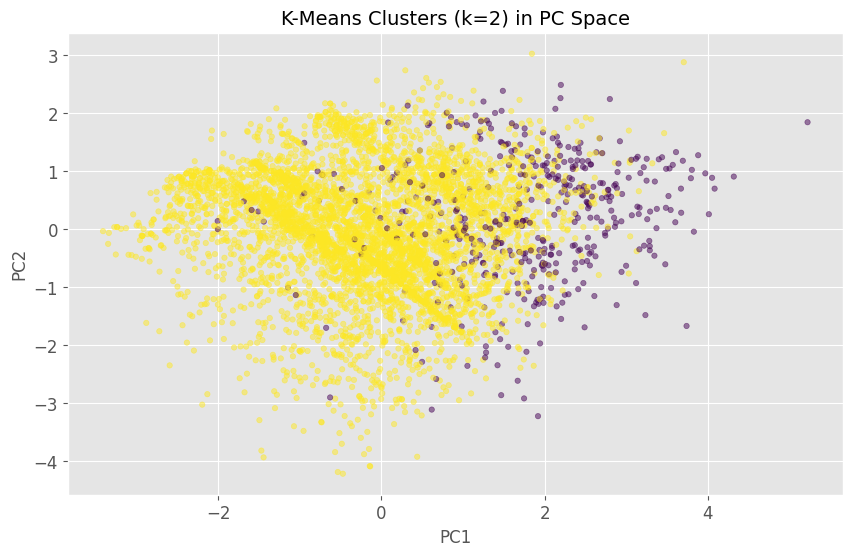


--- KMeans (k=3) ---
Silhouette Score: 0.1864

Cross-tab (Cluster vs Label):
Income       0     1
Cluster             
0        11252  7657
1        17564   786
2          908   906
Overall Purity: 0.7607


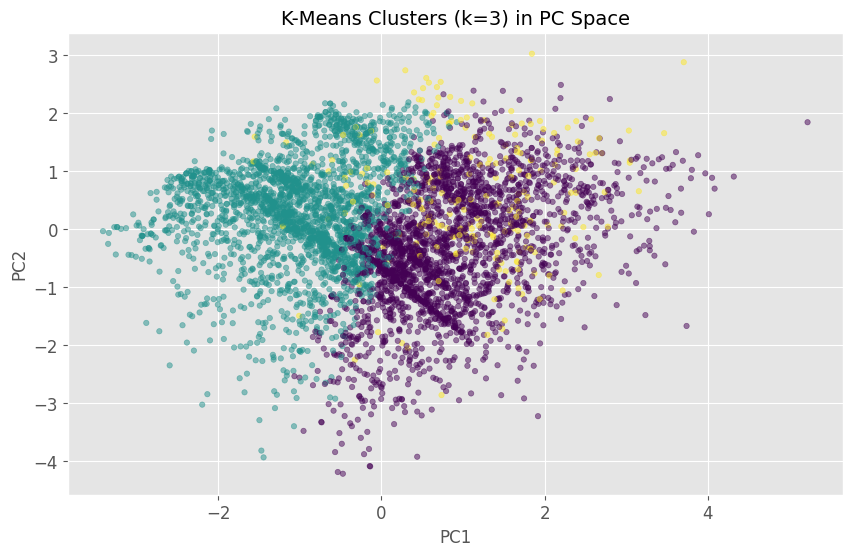

In [6]:
n_pcs = 10
X_reduced = X_train_pca[:, :n_pcs]

for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    clusters = kmeans.fit_predict(X_reduced)
    
    # Silhouette Score (sampled for speed)
    sil = silhouette_score(X_reduced[sample_idx], clusters[sample_idx])
    print(f"\n--- KMeans (k={k}) ---")
    print(f"Silhouette Score: {sil:.4f}")
    
    # Purity Analysis
    df_cluster = pd.DataFrame({'Cluster': clusters, 'Income': y_train})
    ct = pd.crosstab(df_cluster['Cluster'], df_cluster['Income'])
    print("\nCross-tab (Cluster vs Label):")
    print(ct)
    
    # Simple Purity calculation
    purity = ct.max(axis=1).sum() / len(df_cluster)
    print(f"Overall Purity: {purity:.4f}")
    
    # Visual Correlation
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train_pca[sample_idx, 0], X_train_pca[sample_idx, 1], c=clusters[sample_idx], cmap='viridis', alpha=0.5, s=15)
    plt.title(f'K-Means Clusters (k={k}) in PC Space')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    save_and_show(f'structure_kmeans_k{k}')

## 4. Final Observations

- **PCA Structure:** High-income and low-income individuals do not form isolated clusters in the primary components. This justifies the use of non-linear models (like Random Forest or Gradient Boosting) which can find complex decision boundaries.
- **Clustering Quality:** The silhouette scores are relatively low, suggesting that the data does not have naturally dense, well-separated convex clusters in the PCA subspace.
- **Cluster Purity:** While clusters indicate some correlation with income levels (purity increases slightly over a random baseline), the unsupervised groupings do not perfectly map to the target label. This confirms that predictive modelling requires the supervision of the income label to be effective.